In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
Grc_df = pd.read_csv("Grocery_dataset.csv")

In [3]:
print("Number of Rows: ", Grc_df.shape[0])
print("Number of Columns: ", Grc_df.shape[1])

Number of Rows:  5000
Number of Columns:  12


In [4]:
Grc_df.head(10)

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.300,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.920,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.500,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.200,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.930,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052
5,FDP36,10.395,Regular,0.000000,Baking Goods,51.4008,OUT018,2009,Medium,Tier 3,Supermarket Type2,556.6088
6,FDO10,13.650,Regular,0.012741,Snack Foods,57.6588,OUT013,1987,High,Tier 3,Supermarket Type1,343.5528
7,FDP10,NaN,Low Fat,0.127470,Snack Foods,107.7622,OUT027,1985,Medium,Tier 3,Supermarket Type3,4022.7636
8,FDH17,16.200,Regular,0.016687,Frozen Foods,96.9726,OUT045,2002,NaN,Tier 2,Supermarket Type1,1076.5986
9,FDU28,19.200,Regular,0.094450,Frozen Foods,187.8214,OUT017,2007,NaN,Tier 2,Supermarket Type1,4710.5350


In [5]:
Grc_df.tail(10)

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
4990,FDE46,18.60,Low Fat,0.015859,Snack Foods,152.9366,OUT017,2007,NaN,Tier 2,Supermarket Type1,453.4098
4991,NCQ53,17.60,Low Fat,0.018905,Health and Hygiene,234.6590,OUT046,1997,Small,Tier 1,Supermarket Type1,8508.9240
4992,NCN42,20.25,Low Fat,0.014281,Household,148.0418,OUT018,2009,Medium,Tier 3,Supermarket Type2,1177.1344
4993,DRH11,5.98,Low Fat,0.075675,Hard Drinks,53.3614,OUT049,1999,Medium,Tier 1,Supermarket Type1,331.5684
4994,NCI42,18.75,Low Fat,0.010382,Household,207.8954,OUT049,1999,Medium,Tier 1,Supermarket Type1,2292.3494
4995,FDT07,5.82,Regular,0.077476,Fruits and Vegetables,255.3330,OUT045,2002,NaN,Tier 2,Supermarket Type1,4870.3270
4996,DRL60,8.52,Low Fat,0.027059,Soft Drinks,153.3682,OUT046,1997,Small,Tier 1,Supermarket Type1,914.8092
4997,FDG20,15.50,Regular,0.126200,Fruits and Vegetables,178.4028,OUT018,2009,Medium,Tier 3,Supermarket Type2,1239.7196
4998,FDF56,16.70,Regular,0.119462,Fruits and Vegetables,182.7976,OUT046,1997,Small,Tier 1,Supermarket Type1,1810.9760
4999,FDV33,9.60,Regular,0.027455,Snack Foods,258.1304,OUT018,2009,Medium,Tier 3,Supermarket Type2,2324.9736


In [6]:
Grc_df.isnull().sum()

Item_Identifier                 0
Item_Weight                   818
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  1439
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

In [7]:
Grc_df["Item_Weight"] = Grc_df["Item_Weight"].fillna(
    Grc_df["Item_Weight"].mean()
)

Grc_df["Outlet_Size"] = Grc_df["Outlet_Size"].fillna(
    Grc_df["Outlet_Size"].mode()[0]
)

In [8]:
Grc_df.isnull().sum()

Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
dtype: int64

In [9]:
print("Number of unique outlet sizes:", Grc_df["Outlet_Size"].nunique())
print("Maximum outlet size:", Grc_df["Outlet_Size"].value_counts().idxmax())
print("Minimum outlet size:", Grc_df["Outlet_Size"].value_counts().idxmin())

Number of unique outlet sizes: 3
Maximum outlet size: Medium
Minimum outlet size: High


In [10]:
Grc_df["Item_Fat_Content"].unique()

<StringArray>
['Low Fat', 'Regular', 'low fat', 'LF', 'reg']
Length: 5, dtype: str

In [11]:
Grc_df["Item_Fat_Content"].nunique()

5

In [12]:
# Show the Item Fat Content types and their counts
print(Grc_df["Item_Fat_Content"].value_counts())

# Standardize values that mean the same thing
Grc_df["Item_Fat_Content"] = Grc_df["Item_Fat_Content"].replace({
    "low fat": "Low Fat",
    "LF": "Low Fat",
    "reg": "Regular"
})

# Check the cleaned result
print(Grc_df["Item_Fat_Content"].value_counts())

Item_Fat_Content
Low Fat    3008
Regular    1679
LF          183
reg          68
low fat      62
Name: count, dtype: int64
Item_Fat_Content
Low Fat    3253
Regular    1747
Name: count, dtype: int64


In [13]:
Grc_new_df = Grc_df.drop(Grc_df.columns[[0, 6]], axis=1)
Grc_new_df.head()

,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,9.30,Low Fat,0.016047,Dairy,249.8092,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,5.92,Regular,0.019278,Soft Drinks,48.2692,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,17.50,Low Fat,0.016760,Meat,141.6180,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,1998,Medium,Tier 3,Grocery Store,732.3800
4,8.93,Low Fat,0.000000,Household,53.8614,1987,High,Tier 3,Supermarket Type1,994.7052


In [14]:
# Show the different supermarket types
print(Grc_new_df["Outlet_Type"].value_counts())

# Create two DataFrames using different supermarket types
SupType_1 = Grc_new_df[Grc_new_df["Outlet_Type"] == "Supermarket Type1"]
SupType_2 = Grc_new_df[Grc_new_df["Outlet_Type"] == "Supermarket Type2"]

# Check the first rows of both DataFrames
print("\nSupType_1:")
display(SupType_1.head())

print("\nSupType_2:")
display(SupType_2.head())

Outlet_Type
Supermarket Type1    3328
Grocery Store         608
Supermarket Type3     538
Supermarket Type2     526
Name: count, dtype: int64

SupType_1:


,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,9.30,Low Fat,0.016047,Dairy,249.8092,1999,Medium,Tier 1,Supermarket Type1,3735.1380
2,17.50,Low Fat,0.016760,Meat,141.6180,1999,Medium,Tier 1,Supermarket Type1,2097.2700
4,8.93,Low Fat,0.000000,Household,53.8614,1987,High,Tier 3,Supermarket Type1,994.7052
6,13.65,Regular,0.012741,Snack Foods,57.6588,1987,High,Tier 3,Supermarket Type1,343.5528
8,16.20,Regular,0.016687,Frozen Foods,96.9726,2002,Medium,Tier 2,Supermarket Type1,1076.5986



SupType_2:


,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
1,5.920,Regular,0.019278,Soft Drinks,48.2692,2009,Medium,Tier 3,Supermarket Type2,443.4228
5,10.395,Regular,0.000000,Baking Goods,51.4008,2009,Medium,Tier 3,Supermarket Type2,556.6088
16,11.800,Low Fat,0.008596,Health and Hygiene,115.3492,2009,Medium,Tier 3,Supermarket Type2,1621.8888
31,18.600,Low Fat,0.080829,Health and Hygiene,96.4436,2009,Medium,Tier 3,Supermarket Type2,2741.7644
32,18.700,Low Fat,0.000000,Snack Foods,256.6672,2009,Medium,Tier 3,Supermarket Type2,3068.0064


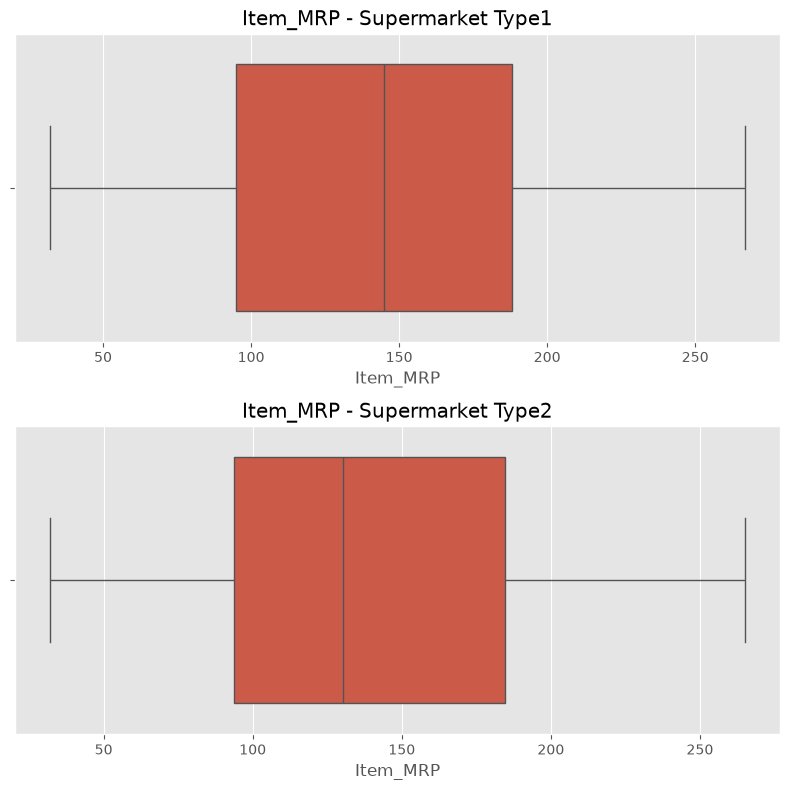

Median MRP for Supermarket Type1: 144.7457
Median MRP for Supermarket Type2: 130.18099999999998


In [15]:

plt.style.use("ggplot")

fig, axes = plt.subplots(2, 1, figsize=(8, 8))

sns.boxplot(x=SupType_1["Item_MRP"], ax=axes[0])
axes[0].set_title("Item_MRP - Supermarket Type1")

sns.boxplot(x=SupType_2["Item_MRP"], ax=axes[1])
axes[1].set_title("Item_MRP - Supermarket Type2")

plt.tight_layout()
plt.show()

print("Median MRP for Supermarket Type1:", SupType_1["Item_MRP"].median())
print("Median MRP for Supermarket Type2:", SupType_2["Item_MRP"].median())

In [16]:
# Concatenate the two DataFrames
Grc_Concat_df = pd.concat([SupType_1, SupType_2])

# Sort by Item_Outlet_Sales in ascending order
Grc_Concat_df = Grc_Concat_df.sort_values(by="Item_Outlet_Sales", ascending=True)

# Show the Outlet Location Type with the lowest sales
print("Outlet Location Type with lowest sales:",
      Grc_Concat_df.iloc[0]["Outlet_Location_Type"])

Outlet Location Type with lowest sales: Tier 3


In [17]:
# Create a multiple index using Outlet_Size and Outlet_Location_Type
Grc_Concat_df = Grc_Concat_df.set_index(["Outlet_Size", "Outlet_Location_Type"])

# Show the result
Grc_Concat_df.head()

Item_Weight Item_Fat_Content  \
Outlet_Size Outlet_Location_Type                                 
High        Tier 3                     20.500          Low Fat   
Medium      Tier 3                      6.635          Regular   
            Tier 3                      6.320          Low Fat   
            Tier 2                      9.105          Low Fat   
Small       Tier 1                     19.250          Low Fat   

                                  Item_Visibility     Item_Type  Item_MRP  \
Outlet_Size Outlet_Location_Type                                            
High        Tier 3                       0.143164     Household   34.9190   
Medium      Tier 3                       0.046278  Frozen Foods   36.7506   
            Tier 3                       0.012770          Meat   39.9822   
            Tier 2                       0.038560     Household   33.8900   
Small       Tier 1                       0.108030     Household   32.4558   

                                  Outlet_Establishment_Year  \
Outlet_Size Outlet_Location_Type                              
High        Tier 3                                     1987   
Medium      Tier 3                                     2009   
            Tier 3                                     2009   
            Tier 2                                     2002   
Small       Tier 1                                     1997   

                                        Outlet_Type  Item_Outlet_Sales  
Outlet_Size Outlet_Location_Type                                        
High        Tier 3                Supermarket Type1            73.2380  
Medium      Tier 3                Supermarket Type2            75.9012  
            Tier 3                Supermarket Type2            78.5644  
            Tier 2                Supermarket Type1            99.8700  
Small       Tier 1                Supermarket Type1           101.8674

In [18]:
# Cut Item_Weight into 10 buckets
Grc_Concat_df["Weight_Bucket"] = pd.cut(Grc_Concat_df["Item_Weight"], bins=10)

# Compute mean, minimum, maximum, and count for each bucket
weight_summary = Grc_Concat_df.groupby("Weight_Bucket")["Item_Weight"].agg(
    ["mean", "min", "max", "count"]
)

# Show the result
weight_summary

,mean,min,max,count
Weight_Bucket,,,,
"(4.538, 6.234]",5.623814,4.555,6.215,253
"(6.234, 7.914]",7.121807,6.235,7.905,476
"(7.914, 9.594]",8.761867,7.930,9.500,450
"(9.594, 11.273]",10.344917,9.600,11.150,362
"(11.273, 12.952]",12.081635,11.300,12.850,419
"(12.952, 14.632]",13.716193,13.000,14.600,352
"(14.632, 16.312]",15.495976,14.650,16.250,410
"(16.312, 17.991]",17.172672,16.350,17.850,408
"(17.991, 19.671]",18.838005,18.000,19.600,396
